# CMSDAS 2026 Hefei — Short Exercise: Machine Learning
# Session #2: Transformers

Course Indico link: https://indico.cern.ch/event/1639697/timetable/?view=standard#263-machine-learning

This notebook is available on the Course [GitLab page](https://gitlab.cern.ch/das-hefei2026/exercise/-/tree/master/Short_exercise/Machine_Learning).

In [ ]:
## Install the lightning package if using SWAN/lxplus-gpu for the first time
## (uncomment and run the lines below)

# !pip install lightning --user

# import os, sys
# sys.path.append(f"{os.environ['HOME']}/.local/lib/python3.13/site-packages")

In [ ]:
import os
import uproot
import awkward as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
import lightning as L
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
import torchmetrics


## Introduction: Why use Transformers?

As the models we design grow larger and the tasks become more complex, Transformers offer distinct advantages. The architecture directly enabled the success of large language models (GPT and BERT), and today most top-performing models across many domains are based on it. The same is true for applications in high-energy physics.

Consider the example of jet tagging:

In both ATLAS and CMS, small-radius (R=0.4) jet flavour identification is used in nearly half of all analyses. This involves using information from all constituent particles of a jet (typically O(30) of them) to train a DNN that classifies whether the jet originates from a b quark. Some analyses also require discrimination against c quarks, light (u/d/s) quarks, or gluons. Such DNN tools are called jet taggers. Because jet tagging is so widely used, training and deploying jet taggers is a central task for both experiments. This classification problem is also more complex than typical physics analyses. With advances in DNN design and training, the latest jet taggers in ATLAS and CMS have adopted the Transformer architecture: ATLAS uses [GN2](https://atlas.web.cern.ch/Atlas/GROUPS/PHYSICS/PLOTS/FTAG-2023-01/), and CMS uses [UParT](https://cds.cern.ch/record/2904702/files/DP2024_066.pdf). The CMS tagger achieves a 50× improvement over early Run-2 in suppressing light-flavour jet background in b-tagging, with no sign of saturation yet. For complex tasks with large datasets, the Transformer architecture is currently essential for achieving the best performance.

You can find more details in tomorrow's [b-tagging session](https://indico.cern.ch/event/1639697/timetable/?view=standard#299-b-tagging-vtx).

<img src="figures/transformers-for-jet-tagging.png" alt="image" width=700/>

Before that, we build a basic Transformer and apply it to a simple classification task for hands-on learning.

## Background

Since its introduction in 2017, the Transformer has dominated many domains—outperforming earlier CNN and RNN architectures in both vision and language tasks—and has become a unifying architecture. Beyond machine learning, it is widely used in scientific research.

It was designed to handle data with two or more dimensions. Here, "two-dimensional data" means a sequence of tokens, where each token is a feature vector.

 - For images: a token can be a 16×16 pixel patch, with features representing the latent-space embedding of that patch.
 - For text: a token can be a word or subword, with features from its embedding.

<img src="figures/token_illustration.jpeg" alt="image" width=900/>

**A useful analogy** (used throughout this tutorial): think of "two-dimensional data" as a classroom of students. Each student has a feature vector (like a mental state of knowledge), and the full dataset is the set of all students. In the image/text examples above, each student corresponds to a pixel patch or a word.

Conventional DNNs (often called multi-layer perceptrons, MLPs) are suited to "one-dimensional" data.
For data with an intrinsic two-dimensional structure, one can flatten it into a one-dimensional vector and feed it to a DNN—but this discards the structure, reducing both learning efficiency and performance.
The Transformer, in contrast, both applies MLP-like operations along the token dimension and efficiently learns relationships between tokens via self-attention, making it well-suited for images, text, and other structured data.

## Prepare the dataset on a token basis

We prepare a dataset where each event's tokens are jets, leptons, and MET. This means implementing the PyTorch Dataset interface. To keep inputs consistent with the previous example, we select two b-jets, two leptons, and one MET. The input information is equivalent but now structured. Below we show a sample event from the dataset.

In [ ]:
# Load with Awkward: jets and leptons are per-event variable-length vectors (jagged arrays).
SIG_PATH = "/eos/user/c/coli/cms-repo/cmsdas/data/train_and_test_sig_hhbbww_1M.root:tree"
BKG_PATH = "/eos/user/c/coli/cms-repo/cmsdas/data/train_and_test_bkg_ttbar_1M.root:tree"

ak_sig = uproot.concatenate(SIG_PATH, library="ak")
ak_bkg = uproot.concatenate(BKG_PATH, library="ak")

def _round2(x):
    if isinstance(x, float):
        return round(x, 2)
    if isinstance(x, list):
        return [_round2(v) for v in x]
    return x

print("=== Inspect branches: print two events (signal file) ===\n")
for name in ak_sig.fields:
    arr = ak_sig[name]
    print(name)
    print(" ", arr.type)
    print(" ", _round2(ak.to_list(arr[1:3])))
    print()

=== Inspect branches: print two events (signal file) ===

jet_pt
  1000000 * var * float32
  [[699.22, 413.56, 234.12, 148.36, 103.56, 64.93, 44.53, 34.81, 34.17, 33.04, 20.44], [435.95, 285.27, 223.49, 18.79]]

jet_eta
  1000000 * var * float32
  [[0.0, -0.13, -1.51, -0.5, -1.07, 0.07, 1.88, 2.52, -1.45, -0.45, -2.16], [-0.16, 0.52, 0.93, 0.51]]

jet_phi
  1000000 * var * float32
  [[-0.65, 2.62, -3.06, 0.88, 0.72, 0.79, -3.13, -2.76, 1.67, -0.71, -3.0], [2.22, -1.33, -0.47, -2.65]]

jet_energy
  1000000 * var * float32
  [[706.05, 417.56, 558.76, 168.47, 169.21, 65.74, 149.02, 218.53, 77.43, 36.62, 89.48], [444.12, 325.26, 329.26, 21.68]]

jet_mass
  1000000 * var * float32
  [[97.98, 23.49, 24.38, 22.38, 14.46, 9.34, 5.39, 2.44, 7.68, 4.04, 3.93], [48.28, 21.36, 41.28, 3.96]]

jet_is_btag
  1000000 * var * int32
  [[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0], [0, 1, 0, 1]]

lep_pt
  1000000 * var * float32
  [[257.71, 166.02], [146.31, 81.17]]

lep_eta
  1000000 * var * float32
  [[-0.08, -0.

In [ ]:
ak_events = ak.concatenate([ak_sig, ak_bkg])
labels = np.concatenate([np.ones(len(ak_sig), dtype=np.int64), np.zeros(len(ak_bkg), dtype=np.int64)])
idx_all = np.arange(len(ak_events))
train_idx, tmp_idx = train_test_split(idx_all, test_size=0.2, random_state=0)
val_idx, test_idx = train_test_split(tmp_idx, test_size=0.5, random_state=0)

# return a flattened matrix of jet features: (pt, eta, phi, E, m)
def _jet_matrix(ev, mask):
    return np.column_stack([ak.to_numpy(ak.flatten(b[mask])) for b in [ev["jet_pt"], ev["jet_eta"], ev["jet_phi"], ev["jet_energy"], ev["jet_mass"]]]).astype(np.float64)

# return a flattened matrix of lepton features: (pt, eta, phi, E, type, iso)
def _lep_matrix(ev):
    pid = ak.to_numpy(ak.flatten(ev["lep_pid"]))
    ltype = np.where(np.abs(pid) == 11, 0.0, 1.0).astype(np.float64)
    return np.column_stack([ak.to_numpy(ak.flatten(ev["lep_pt"])), ak.to_numpy(ak.flatten(ev["lep_eta"])), ak.to_numpy(ak.flatten(ev["lep_phi"])), ak.to_numpy(ak.flatten(ev["lep_energy"])), ltype, ak.to_numpy(ak.flatten(ev["lep_iso"]))]).astype(np.float64)

# scale and pad the matrix to the regular length
def _scale_pad_jagged(matrix, scaler, counts, max_len, feat_dim):
    if matrix.size == 0:
        n = len(counts)
        return np.zeros((n, max_len, feat_dim), dtype=np.float32), np.zeros((n, max_len), dtype=bool)
    scaled = scaler.transform(matrix).astype(np.float32)
    jagged = ak.unflatten(ak.Array(scaled), counts, axis=0)
    padded = np.asarray(ak.fill_none(ak.pad_none(jagged, max_len, axis=1, clip=True), 0.0), dtype=np.float32)
    masks = np.arange(max_len) < np.minimum(ak.to_numpy(counts), max_len)[:, None]
    return padded, masks


MAX_JETS, MAX_LEPS = 2, 2
train_ev = ak_events[train_idx]
is_b_tr = train_ev["jet_is_btag"] == 1
jm_tr = _jet_matrix(train_ev, is_b_tr)
lm_tr = _lep_matrix(train_ev)
jet_scaler = StandardScaler().fit(jm_tr if jm_tr.size > 0 else np.zeros((1, 5)))
lep_scaler = StandardScaler().fit(lm_tr if lm_tr.size > 0 else np.zeros((1, 6)))
met_scaler = StandardScaler().fit(np.column_stack([ak.to_numpy(train_ev["met_pt"]), ak.to_numpy(train_ev["met_phi"])]).astype(np.float64))

is_b = ak_events["jet_is_btag"] == 1
jet_mat = _jet_matrix(ak_events, is_b)
counts_j = ak.num(ak_events["jet_pt"][is_b])
jets_pre, jet_masks_pre = _scale_pad_jagged(jet_mat, jet_scaler, counts_j, MAX_JETS, 5)

lep_mat = _lep_matrix(ak_events)
counts_l = ak.num(ak_events["lep_pt"])
leps_pre, lep_masks_pre = _scale_pad_jagged(lep_mat, lep_scaler, counts_l, MAX_LEPS, 6)

mets_pre = met_scaler.transform(np.column_stack([ak.to_numpy(ak_events["met_pt"]), ak.to_numpy(ak_events["met_phi"])]).astype(np.float64)).astype(np.float32)


class EventDataset(Dataset):
    """Lightweight: takes precomputed arrays, __getitem__ only indexes. No collate_fn needed."""

    def __init__(self, indices, jets_pre, leps_pre, mets_pre, jet_masks_pre, lep_masks_pre, labels):
        self.indices = np.asarray(indices, dtype=np.int64)
        self.jets_pre = jets_pre
        self.leps_pre = leps_pre
        self.mets_pre = mets_pre
        self.jet_masks_pre = jet_masks_pre
        self.lep_masks_pre = lep_masks_pre
        self.labels = labels

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = int(self.indices[idx])
        batch_dict = {
            "jet": torch.from_numpy(self.jets_pre[i].copy()),
            "lep": torch.from_numpy(self.leps_pre[i].copy()),
            "met": torch.from_numpy(self.mets_pre[i].copy()),
            "jet_mask": torch.from_numpy(self.jet_masks_pre[i].copy()),
            "lep_mask": torch.from_numpy(self.lep_masks_pre[i].copy()),
        }
        return batch_dict, int(self.labels[i])

As seen below, each event has two b-jets, two leptons, and one MET.

In [ ]:
# Example: sample one event
dataset_example = EventDataset(train_idx, jets_pre, leps_pre, mets_pre, jet_masks_pre, lep_masks_pre, labels)
batch_dict, label = dataset_example[0]
jet_features = batch_dict["jet"]
lep_features = batch_dict["lep"]
met_features = batch_dict["met"]
event_idx = int(dataset_example.indices[0])
event = ak_events[event_idx]
print(f"Sample event (index {event_idx}): label={label} ({'signal' if label else 'background'})")
print(f"  Shapes: jets {jet_features.shape}, leps {lep_features.shape}, met {met_features.shape}")
print("  Jets (pt, eta, phi, E, m):")
for j in range(jet_features.shape[0]):
    print(f"    jet {j}: {[round(x.item(), 2) for x in jet_features[j]]}")
print("  Leptons (pt, eta, phi, E, type, iso):")
for k in range(lep_features.shape[0]):
    print(f"    lep {k}: {[round(x.item(), 2) for x in lep_features[k]]}")
print(f"  MET: pt={met_features[0].item():.2f}, phi={met_features[1].item():.2f}")
print("  Raw event (before scaling): n_jets={}, n_leps={}".format(len(event["jet_pt"]), len(event["lep_pt"])))


Sample event (index 608812): label=1 (signal)
  Shapes: jets torch.Size([2, 5]), leps torch.Size([2, 6]), met torch.Size([2])
  Jets (pt, eta, phi, E, m):
    jet 0: [3.0, -0.78, -1.54, 2.14, 1.51]
    jet 1: [-0.63, -0.89, -1.01, -0.6, -0.51]
  Leptons (pt, eta, phi, E, type, iso):
    lep 0: [2.91, -0.41, -1.23, 1.49, -1.08, -0.04]
    lep 1: [0.83, -0.17, -1.24, 0.1, -1.08, -0.05]
  MET: pt=1.37, phi=-1.10
  Raw event (before scaling): n_jets=4, n_leps=2


Initiate the dataset and data loader.

In [ ]:
train_ds_tfm = EventDataset(train_idx, jets_pre, leps_pre, mets_pre, jet_masks_pre, lep_masks_pre, labels)
val_ds_tfm = EventDataset(val_idx, jets_pre, leps_pre, mets_pre, jet_masks_pre, lep_masks_pre, labels)
train_loader_tfm = DataLoader(train_ds_tfm, batch_size=1024, num_workers=4, shuffle=True)
val_loader_tfm = DataLoader(val_ds_tfm, batch_size=1024, num_workers=4, shuffle=False)

## Building a Transformer network

### Intuition

How does the Transformer architecture process each token (each student's knowledge) and efficiently extract information?

1. Embed the initial tokens—each student updates their knowledge using the same procedure. Embedding applies a nonlinear transformation from the raw input into a latent space, so that the new vectors capture more abstract information (e.g., words with similar meanings have similar latent-space vectors).
2. For the embedded tokens, repeatedly apply Transformer blocks (multi-head self-attention). Self-attention can be understood as an efficient communication mechanism and is the focus of this section. As in the video, it proceeds in two steps:
    - Multi-head self-attention—the core of communication (the attention part)
    - Apply two nonlinear transformations to extract abstract features (the feed-forward network, FFN part)
3. Finally, we need to aggregate everyone's knowledge. How? We introduce a class token from the start—a special student. It first communicates with all other students, learns from them, and updates its own knowledge. This student's final vector summarizes the knowledge of all students.

### Embedding layer
We implement it step by step, starting with the embedding layer.


In [ ]:
class Embed(nn.Module):
    """Three MLPs: jet (5), lepton (6), MET (2). Sequence: [CLS] + all jets + all leptons + MET."""

    def __init__(self, config):
        super().__init__()
        d = config.hidden_size
        self.jet_emb = nn.Sequential(nn.Linear(5, d), nn.GELU(), nn.Linear(d, d))
        self.lep_emb = nn.Sequential(nn.Linear(6, d), nn.GELU(), nn.Linear(d, d))
        self.met_emb = nn.Sequential(nn.Linear(2, d), nn.GELU(), nn.Linear(d, d))
        self.cls_token = nn.Parameter(torch.randn(1, 1, d))
        self.norm = nn.LayerNorm(d)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)

    def forward(self, jet, lep, met, jet_mask, lep_mask):
        # Input shapes:
        #   jet: (B, Nj, 5)   – batch, max jets, features (pt, eta, phi, E, m)
        #   lep: (B, Nl, 6)   – batch, max leptons, features (pt, eta, phi, E, type, iso)
        #   met: (B, 2)       – batch, features (pt, phi)
        #   jet_mask: (B, Nj) – True = real jet (non-padded)
        #   lep_mask: (B, Nl) – True = real lepton (non-padded)

        B = jet.size(0)
        hj = self.jet_emb(jet)
        hl = self.lep_emb(lep)
        hm = self.met_emb(met).unsqueeze(1)
        cls = self.cls_token.expand(B, -1, -1)

        # concat tokens: [CLS] + all jets + all leptons + MET
        x = torch.cat([cls, hj, hl, hm], dim=1)
        
        # key_padding_mask: True = ignore in attention (padded jet/lepton positions)
        jet_padding_mask = ~jet_mask
        lep_padding_mask = ~lep_mask
        key_padding_mask = torch.cat(
            [
                torch.zeros(B, 1, dtype=torch.bool, device=jet.device),
                jet_padding_mask,
                lep_padding_mask,
                torch.zeros(B, 1, dtype=torch.bool, device=jet.device),
            ],
            dim=1,
        )
        x = self.norm(x)
        x = self.dropout(x)
        return x, key_padding_mask

The input consists of `Nj=2` b-jets, `Nl=2` leptons, and one MET. 

In the forward pass, each is embedded to the same dimension (d=config.hidden_size) and concatenated directly. The token sequence is: [CLS] + all jets + all leptons + MET.
We also compute `key_padding_mask` so that padded tokens are ignored in self-attention. In this setup, however, every token is genuine—there are no zero-padding tokens.

### A Transformer block

Think of each student in the classroom as a token. How do they perform one round of "communication" to update their knowledge?

 - First, pass through a linear layer to map each student's feature vector (a 1D vector of fixed length) to three vectors: Q (query), K (key), and V (value).
 - Each student then interacts with all others by computing the dot product of their Q vector with each other student's K vector. In this way, each student is connected to all others via dot products (see the figure below).
 - For each student, there are N dot products (one with each of the N students, including themselves). Apply softmax to obtain N weights—the "importance" of each student to the current one.
 - Weight each student's V vector by these weights and sum—this gives each student's updated vector.

After one such operation, each student's vector becomes a weighted sum of all students' vectors. This is the idea behind self-attention.


<img src="figures/token-in-classroom.png" alt="image" width=900/>

The figure below summarizes one attention computation.

<img src="figures/attention-illustration.png" alt="image" width=600/>

We use multi-head self-attention—multiple attention heads in parallel. The idea is simple: split each student's Q, K, and V vectors into num_heads parts, apply the above procedure to each part separately, then concatenate the outputs. This improves performance because each head can attend to different students and extract different information.

After one round of communication, an FFN applies a nonlinear mapping to further extract information from the exchange.

A Transformer block is built from attention plus FFN, along with two key ingredients: Layer Normalization and residual connections. See the implementation below.

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_hidden_dim, attn_dropout=0.1, dropout=0.1):
        super(TransformerBlock, self).__init__()
        # Multi-head self-attention layer
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=attn_dropout, batch_first=True)
        # First layer normalization (applied before attention)
        self.norm1 = nn.LayerNorm(embed_dim)
        # Feed-forward network: two linear layers with GELU activation in between
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_hidden_dim),
            nn.GELU(),
            nn.Linear(ff_hidden_dim, embed_dim),
        )
        # Second layer normalization (applied before feed-forward)
        self.norm2 = nn.LayerNorm(embed_dim)
        # Dropout layer for regularization
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        # Apply first layer normalization before self-attention
        x = self.norm1(x)
        # Self-attention: Q, K, V are all set to x (self-attention).
        # key_padding_mask: True at padded jet/lepton positions (ignored by attention).
        attn_output, _ = self.attention(x, x, x, key_padding_mask=key_padding_mask)
        # Add & Norm: residual connection after attention + dropout
        x = x + self.dropout(attn_output)

        # Apply second layer normalization before feed-forward
        x = self.norm2(x)
        # Feed-forward network
        ff_output = self.ff(x)
        # Add & Norm: residual connection after feed-forward + dropout
        x = x + self.dropout(ff_output)

        return x

In summary, a Transformer block takes `x` (the vector representation of each token) as input and returns `x`:

 1. Apply Layer Normalization to `x` (normalize each token to zero mean, unit variance).
 2. Apply self-attention so tokens communicate (the operation summarized in the figure above).
 3. Add the result to the original `x` (residual connection).
 4. Apply Layer Normalization again.
 5. Apply the FFN for a nonlinear mapping that extracts information from the exchange.
 6. Add the result to `x` (residual connection).
 7. Return `x`.

### Stacking the Transformer block
Finally, we stack multiple Transformer blocks to build a Transformer network. See the implementation below.

In [ ]:
class TransformerNet(nn.Module):
    def __init__(self, config):
        super().__init__()
        # Embedding layer: jagged jets/leptons + MET -> token sequence
        self.embed = Embed(config)
        # Stack of transformer blocks
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(
                    config.hidden_size,
                    config.num_attention_heads,
                    config.intermediate_size,
                    attn_dropout=config.attn_dropout_prob,
                    dropout=config.hidden_dropout_prob,
                )
                for _ in range(config.num_hidden_layers)
            ]
        )
        # Dropout before final classification
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        # Final linear layer for classification
        self.head = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, batch):
        jet, lep, met = batch["jet"], batch["lep"], batch["met"]
        jet_mask, lep_mask = batch["jet_mask"], batch["lep_mask"]
        # Pass input through embedding layer (also builds padding mask for attention)
        x, key_padding_mask = self.embed(jet, lep, met, jet_mask, lep_mask)
        # Pass through each transformer block
        for block in self.blocks:
            x = block(x, key_padding_mask=key_padding_mask)
        # Select the hidden state corresponding to the [CLS] token (first token)
        x = x[:, 0, :]
        # Apply dropout
        x = self.dropout(x)
        # Final classification layer
        return self.head(x)

Below we define a LightningModule for training and validation.


In [ ]:
from types import SimpleNamespace
config = SimpleNamespace(
    hidden_size = 16,          # Hidden size for embeddings and Transformer
    num_attention_heads = 4,   # Number of attention heads
    intermediate_size = 64,    # Feed forward intermediate size
    num_hidden_layers = 4,     # Number of Transformer layers
    hidden_dropout_prob = 0.,  # Dropout probability
    attn_dropout_prob = 0.,    # Attention dropout probability
    num_labels = 2             # Number of output classes
)

class LitTransformer(L.LightningModule):
    def __init__(self, config):
        super().__init__()
        self.mod = TransformerNet(config)
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=config.num_labels)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=config.num_labels)

    def forward(self, batch):
        return self.mod(batch)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.train_acc(logits, y)
        self.log("train_loss", loss)
        self.log("train_acc", self.train_acc, on_step=False, on_epoch=True)
        self.log("lr", self.trainer.optimizers[0].param_groups[0]["lr"])
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.val_acc(logits, y)
        self.log("val_loss", loss)
        self.log("val_acc", self.val_acc, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.01)

        def lr_lambda(epoch):
            if epoch < 0.7 * self.trainer.max_epochs:
                return 1.0
            decay_factor = (epoch - 0.7 * self.trainer.max_epochs) / (0.3 * self.trainer.max_epochs)
            return 0.01 ** decay_factor

        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
        return [optimizer], [scheduler]


model_transformer = LitTransformer(config)
print(model_transformer)  ## self-check: understand each part of the model

LitTransformer(
  (mod): TransformerNet(
    (embed): Embed(
      (jet_emb): Sequential(
        (0): Linear(in_features=5, out_features=16, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=16, out_features=16, bias=True)
      )
      (lep_emb): Sequential(
        (0): Linear(in_features=6, out_features=16, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=16, out_features=16, bias=True)
      )
      (met_emb): Sequential(
        (0): Linear(in_features=2, out_features=16, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=16, out_features=16, bias=True)
      )
      (norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (blocks): ModuleList(
      (0-3): 4 x TransformerBlock(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
        )
   

Compare the model output above with the Transformer block structure described earlier. Can you match each component?

Let's start training.

In [ ]:
# Trainer with a logger (you may change the name here!)
trainer = L.Trainer(accelerator="gpu", devices=1, max_epochs=20, logger=L.pytorch.loggers.TensorBoardLogger("tb_logs", name="simple_transformer"))

# Fit the model (jagged jet/lepton + MET loaders)
trainer.fit(model_transformer, train_loader_tfm, val_loader_tfm)

## Performance evaluation

We use the trained model to perform inference on the test set and obtain the predictions.

In [ ]:
test_ds_tfm = EventDataset(test_idx, jets_pre, leps_pre, mets_pre, jet_masks_pre, lep_masks_pre, labels)
test_loader_tfm = DataLoader(test_ds_tfm, batch_size=1024, shuffle=False)

# If your model is saved, load it
# model_transformer = LitTransformer.load_from_checkpoint('path_to_checkpoint.ckpt', config=config)

# Inference on test set
model_transformer.eval()
all_logits = []
with torch.no_grad():
    for batch, _ in test_loader_tfm:
        logits = model_transformer(batch)
        all_logits.append(logits.cpu().numpy())
test_logits = np.concatenate(all_logits, axis=0)

# Apply softmax to get probabilities (signal = class 1)
test_score = np.exp(test_logits[:, 1]) / (np.exp(test_logits[:, 0]) + np.exp(test_logits[:, 1]))
test_labels = labels[test_idx]

Below we plot the score distribution.

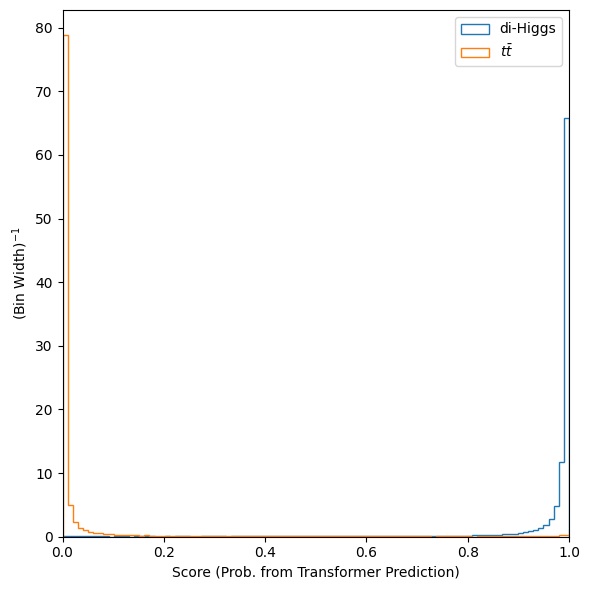

In [ ]:
# Score distribution: signal vs background
fig, ax1 = plt.subplots(1, 1, figsize=(6, 6))
ax1.hist(test_score[test_labels == 1], label=r"di-Higgs", histtype="step", bins=np.linspace(0, 1, 100), density=True)
ax1.hist(test_score[test_labels == 0], label=r"$t\bar{t}$", histtype="step", bins=np.linspace(0, 1, 100), density=True)
ax1.set_xlabel("Score (Prob. from Transformer Prediction)")
ax1.set_ylabel("(Bin Width)$^{-1}$")
ax1.set_xlim(0, 1)
ax1.legend()
plt.tight_layout()
plt.show()

Draw the ROC curve and compare it with the XGBoost and simple DNN curves.

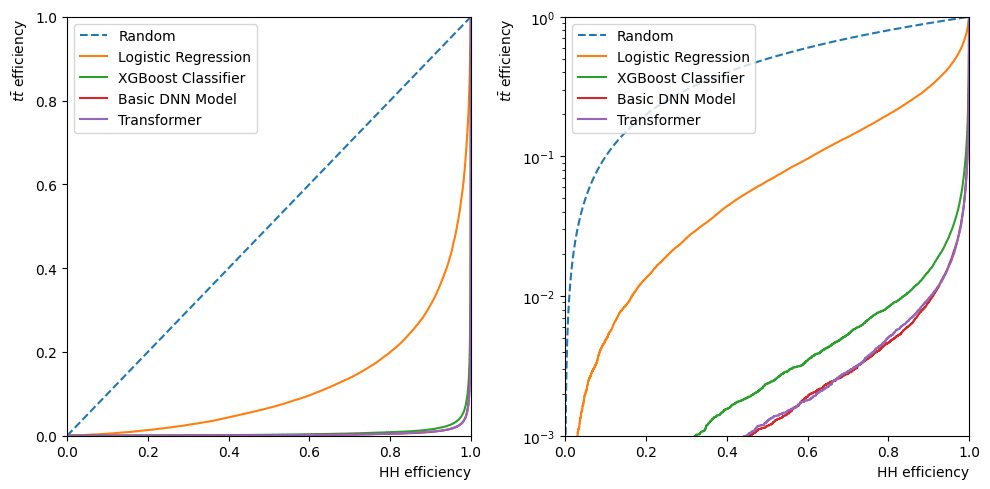

In [ ]:
# Draw the ROC curve (linear + log, compare with LR/XGB if data exist)
import sklearn.metrics as m
fpr, tpr, _thres = m.roc_curve(test_labels, test_score)

f = plt.figure(figsize=(10, 5), tight_layout=True)
ax1 = f.add_subplot(1, 2, 1)
ax2 = f.add_subplot(1, 2, 2)

for ax, ax_type in zip([ax1, ax2], ['linear', 'log']):
    ax.plot(np.linspace(0, 1, 1000), np.linspace(0, 1, 1000), '--', label='Random')
    dat = np.loadtxt("data/roc_lr.dat")
    tpr_clf, fpr_clf = (dat[0], dat[1])
    ax.plot(tpr_clf, fpr_clf, label='Logistic Regression')

    dat = np.loadtxt("data/roc_xgb.dat")
    tpr_xgb, fpr_xgb = (dat[0], dat[1])
    ax.plot(tpr_xgb, fpr_xgb, label='XGBoost Classifier')
    
    dat = np.loadtxt("data/roc_dnn.dat")
    tpr_dnn, fpr_dnn = (dat[0], dat[1])
    ax.plot(tpr_dnn, fpr_dnn, label='Basic DNN Model')

    ax.plot(tpr, fpr, label=f'Transformer')
    if ax_type == 'linear':
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    elif ax_type == 'log':
        ax.set_xlim(0, 1)
        ax.set_ylim(1e-3, 1)
        ax.set_yscale('log')
    ax.set_xlabel('HH efficiency', ha='right', x=1.0)
    ax.set_ylabel(r'$t\bar{t}$ efficiency', ha='right', y=1.0)
    ax.legend()

plt.show()

Save the ROC curve data for later use.

In [ ]:
os.makedirs('data', exist_ok=True)
np.savetxt("data/roc_transformer.dat", [tpr, fpr])

## Exercise 2
1. Complete training with the default configuration. View the metrics in the same TensorBoard interface and compare them with the previous DNN training curves. What do you observe?
2. Set `num_heads` to 1. How does the training result change?
3. Transformers have used GELU activation by default since their inception. Change the activation to ReLU and observe how the training result changes.

Compare the TensorBoard metrics and ROC curves from all these runs (see `hw.md` for an example).